In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print(X.head())
print(y.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
#Euclidean Distance 
euclidean_accuracy = []

for k in range(1,16):
    model = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    euclidean_accuracy.append(acc)

In [7]:
# Manhattan Distance
manhattan_accuracy = []

for k in range(1,16):
    
    model = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions) 
    manhattan_accuracy.append(acc)

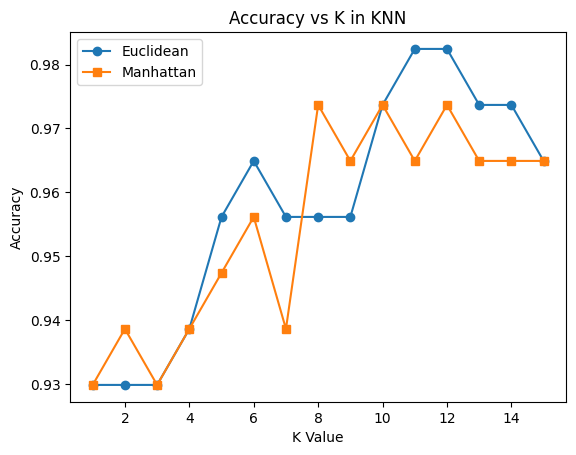

In [8]:
plt.figure()

plt.plot(range(1,16), euclidean_accuracy, marker='o', label='Euclidean')
plt.plot(range(1,16), manhattan_accuracy, marker='s', label='Manhattan')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K in KNN")

plt.legend()
plt.show()

In [9]:
results = pd.DataFrame({
    "K": range(1,16),
    "Euclidean Accuracy": euclidean_accuracy,
    "Manhattan Accuracy": manhattan_accuracy
})

results

,K,Euclidean Accuracy,Manhattan Accuracy
0,1,0.929825,0.929825
1,2,0.929825,0.938596
2,3,0.929825,0.929825
3,4,0.938596,0.938596
4,5,0.956140,0.947368
5,6,0.964912,0.956140
6,7,0.956140,0.938596
7,8,0.956140,0.973684
8,9,0.956140,0.964912
9,10,0.973684,0.973684
